In [1]:
import Pkg
using Sunny, GLMakie, StaticArrays, LinearAlgebra

In [2]:
units = Units(:meV, :angstrom);

In [284]:
latvecs = lattice_vectors(7.3177, 7.3177, 17.534, 90, 90, 120)
fe_cryst = Crystal(latvecs, [[1/6, 5/6, 5/6]], 166)

# cryst = Crystal("ammoniojarosite.cif")
# fe_cryst = subcrystal(cryst, "Fe")
moments = [1 => Moment(s=5/2, g=2)]  
sys = System(fe_cryst, moments, :dipole; dims=(12, 12, 6))

D = [0, 0.218, -0.195]
set_exchange!(sys, 3.3*Matrix(I, 3, 3) + dmvec(D), Bond(1, 2, [0, 0, 0]))
set_exchange!(sys, 0.11, Bond(1, 2, [1, 0, 0]))
set_exchange!(sys, 0.11, Bond(1, 2, [0, 1, 0]))

In [175]:
randomize_spins!(sys)
minimize_energy!(sys)
#display(plot_spins(sys; color=[S[3] for S in sys.dipoles]))

Converged in 390 iterations

In [188]:
qs1 = [[0, 0, 0], [1/3, 1/3, 0], [1/2, 0, 0], [0, 0, 0]]
qs2 = [[0, 0, 3], [1/3, 1/3, 3], [1/2, 0, 3], [0, 0, 3]]
qs3 = [[0, 0, 6], [1/3, 1/3, 6], [1/2, 0, 6], [0, 0, 6]]
labels = ["Γ", "K", "M", "Γ"]
path1 = q_space_path(fe_cryst, qs1, 150; labels)
path2 = q_space_path(fe_cryst, qs2, 150; labels)
path3 = q_space_path(fe_cryst, qs3, 150; labels)

kernel = lorentzian(fwhm=0.8)
energies = range(0, 25, 150)

0.0:0.16778523489932887:25.0

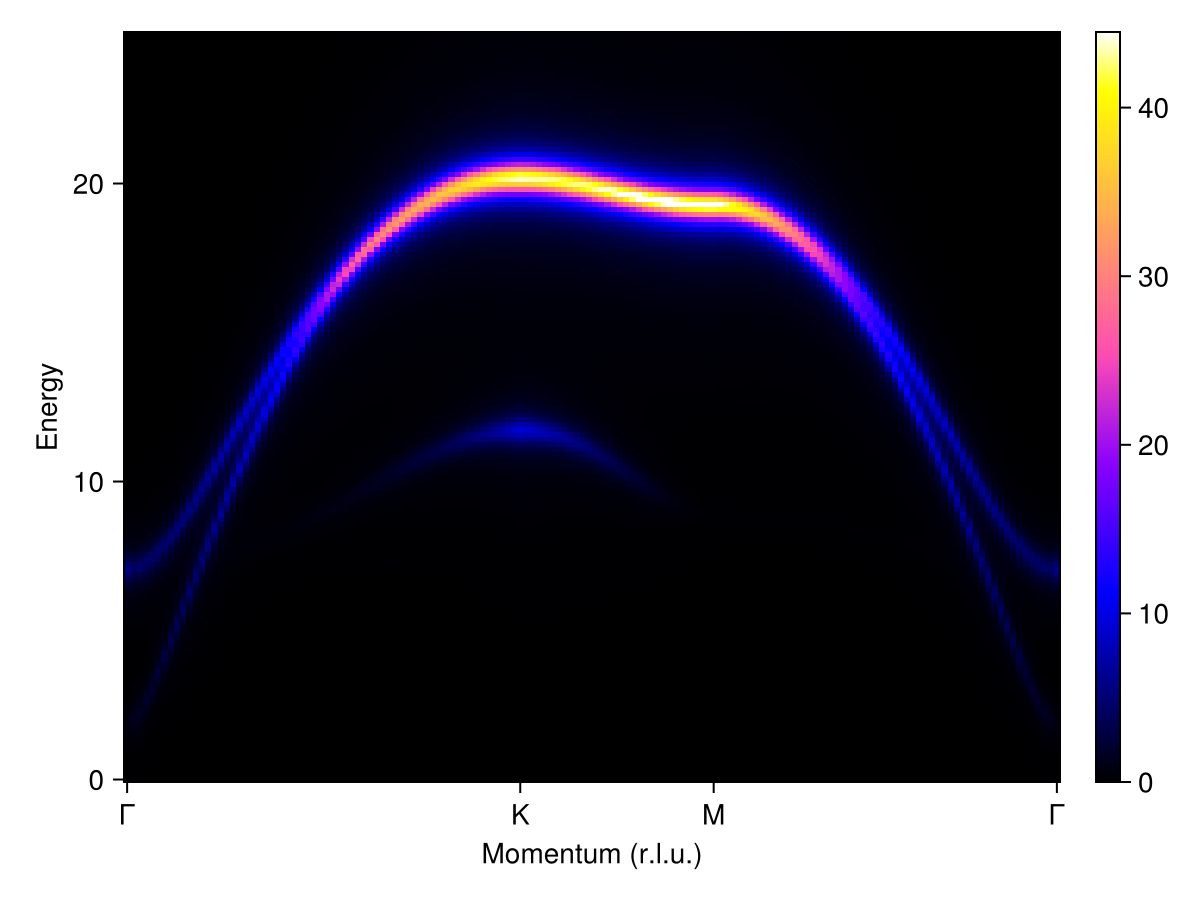

In [189]:
swt = SpinWaveTheory(sys; measure=ssf_perp(sys))
res1 = intensities(swt, path1; energies, kernel)
plot_intensities(res1)

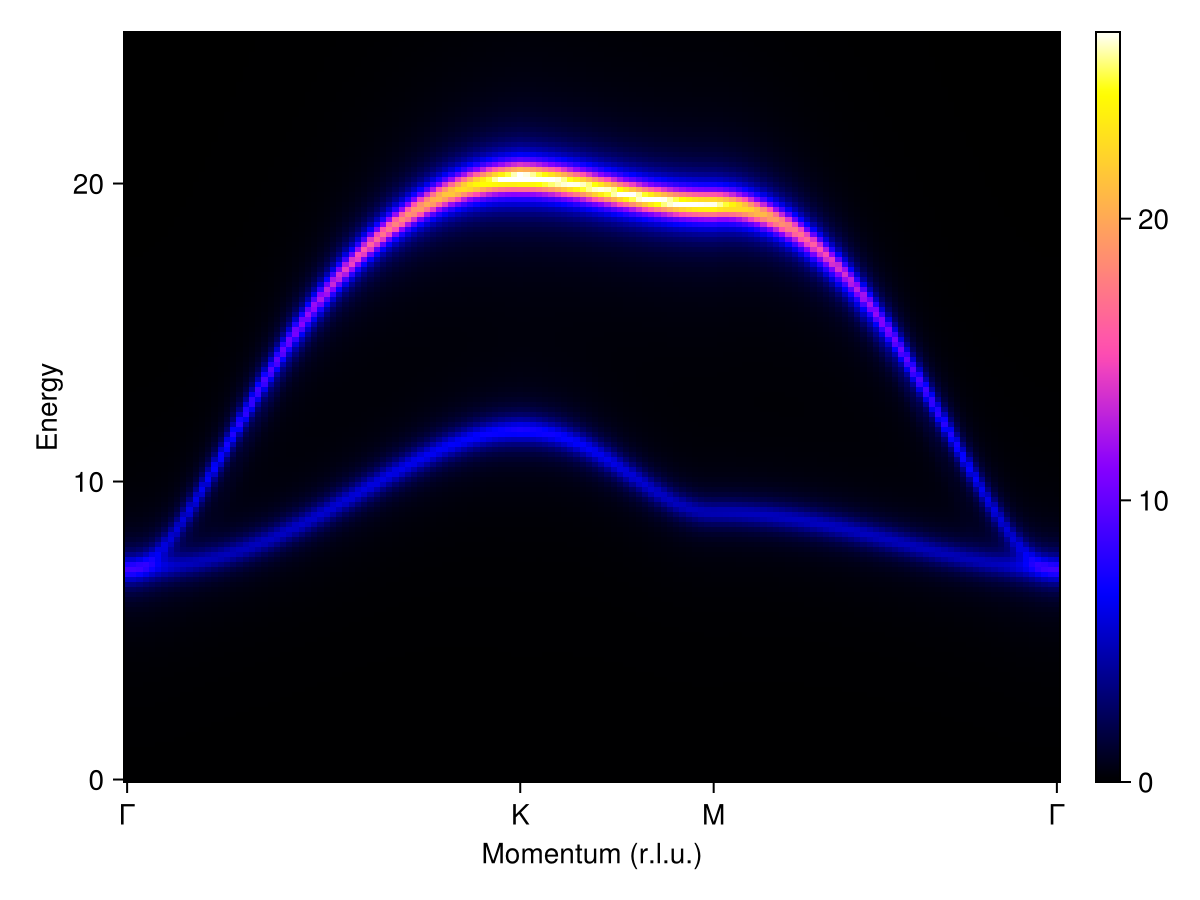

In [190]:
res2 = intensities(swt, path2; energies, kernel)
plot_intensities(res2)

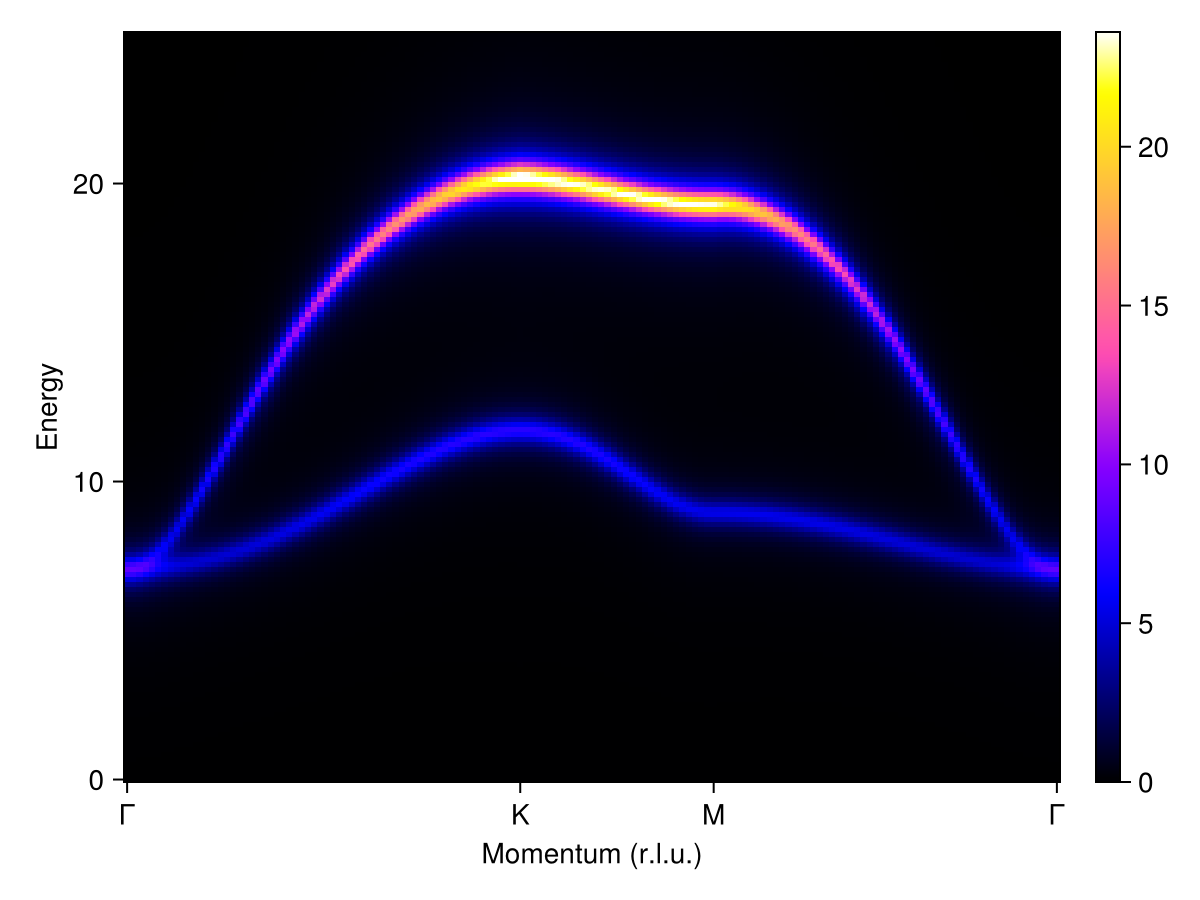

In [ ]:
res3 = intensities(swt, path3; energies, kernel)
plot_intensities(res3)

In [192]:
res_data = (res1.data + res2.data + res3.data)/3
res_e = (res1.energies + res2.energies + res3.energies)/3

filepath = joinpath(@__DIR__, "resdata.txt")
filepath2 = joinpath(@__DIR__, "resE.txt")
open(filepath, "w") do f
    for row in eachrow(res_data)
        println(f, join(row, ", "))
    end
end
open(filepath2, "w") do f
    for row in eachrow(res_e)
        println(f, join(row, ", "))
    end
end

In [302]:
for T in range(35,45, 31)
    langevin = Langevin(; damping = 0.2, kT = T*units.K)
    suggest_timestep(sys, langevin; tol=1e-2)
    langevin.dt = 0.004726;
    energies = [energy_per_site(sys)]
    for _ in 1:1000
        step!(sys, langevin)
        push!(energies, energy_per_site(sys))
    end
    filepath = joinpath(@__DIR__, "E$(T).txt")
    open(filepath, "w") do f
        for row in eachrow(energies)
            println(f, join(row, ", "))
        end
    end    
end    

Consider dt ≈ 0.004637 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004621 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004625 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004628 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004631 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004634 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004637 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004641 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004644 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004647 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004650 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004653 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004656 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004660 for this spin configuration at tol = 0.01000.
Consider dt ≈ 0.004664 for this sp

In [292]:
langevin = Langevin(; damping=0.2, kT=41*units.K)
suggest_timestep(sys, langevin; tol=1e-2)
langevin.dt = 0.004726;

Consider dt ≈ 0.004959 for this spin configuration at tol = 0.01000.


In [293]:
energies = [energy_per_site(sys)]
for _ in 1:1000
    step!(sys, langevin)
    push!(energies, energy_per_site(sys))
end

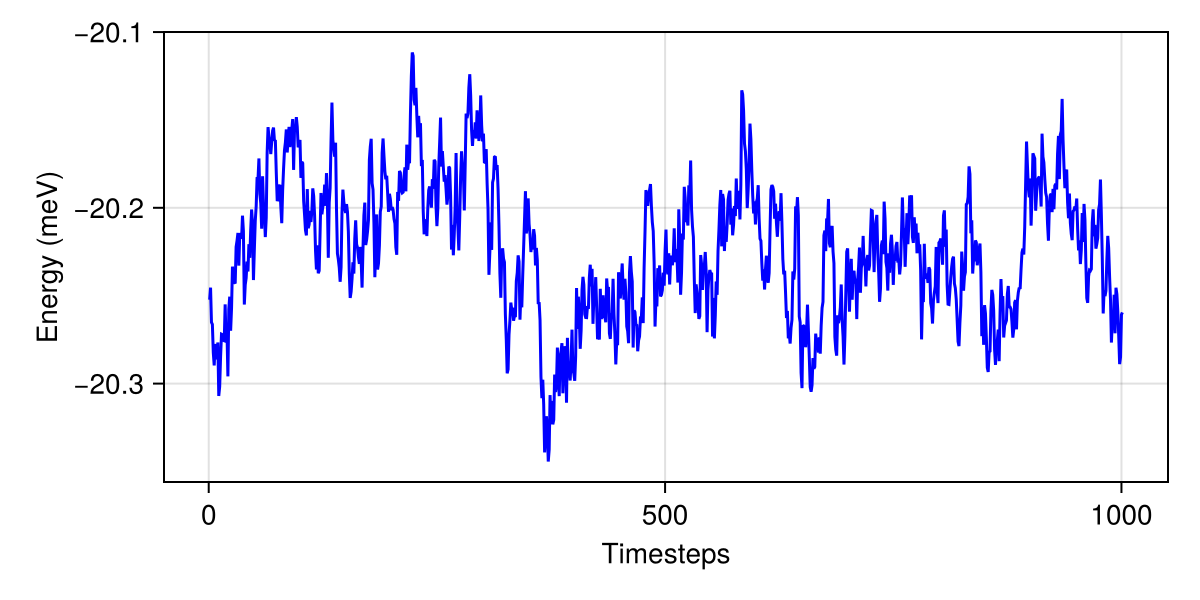

In [294]:
lines(energies, color=:blue, figure=(size=(600,300),), axis=(xlabel="Timesteps", ylabel="Energy (meV)"))

In [288]:
filepath = joinpath(@__DIR__, "energies 41K.txt")
open(filepath, "w") do f
    for row in eachrow(energies)
        println(f, join(row, ", "))
    end
end

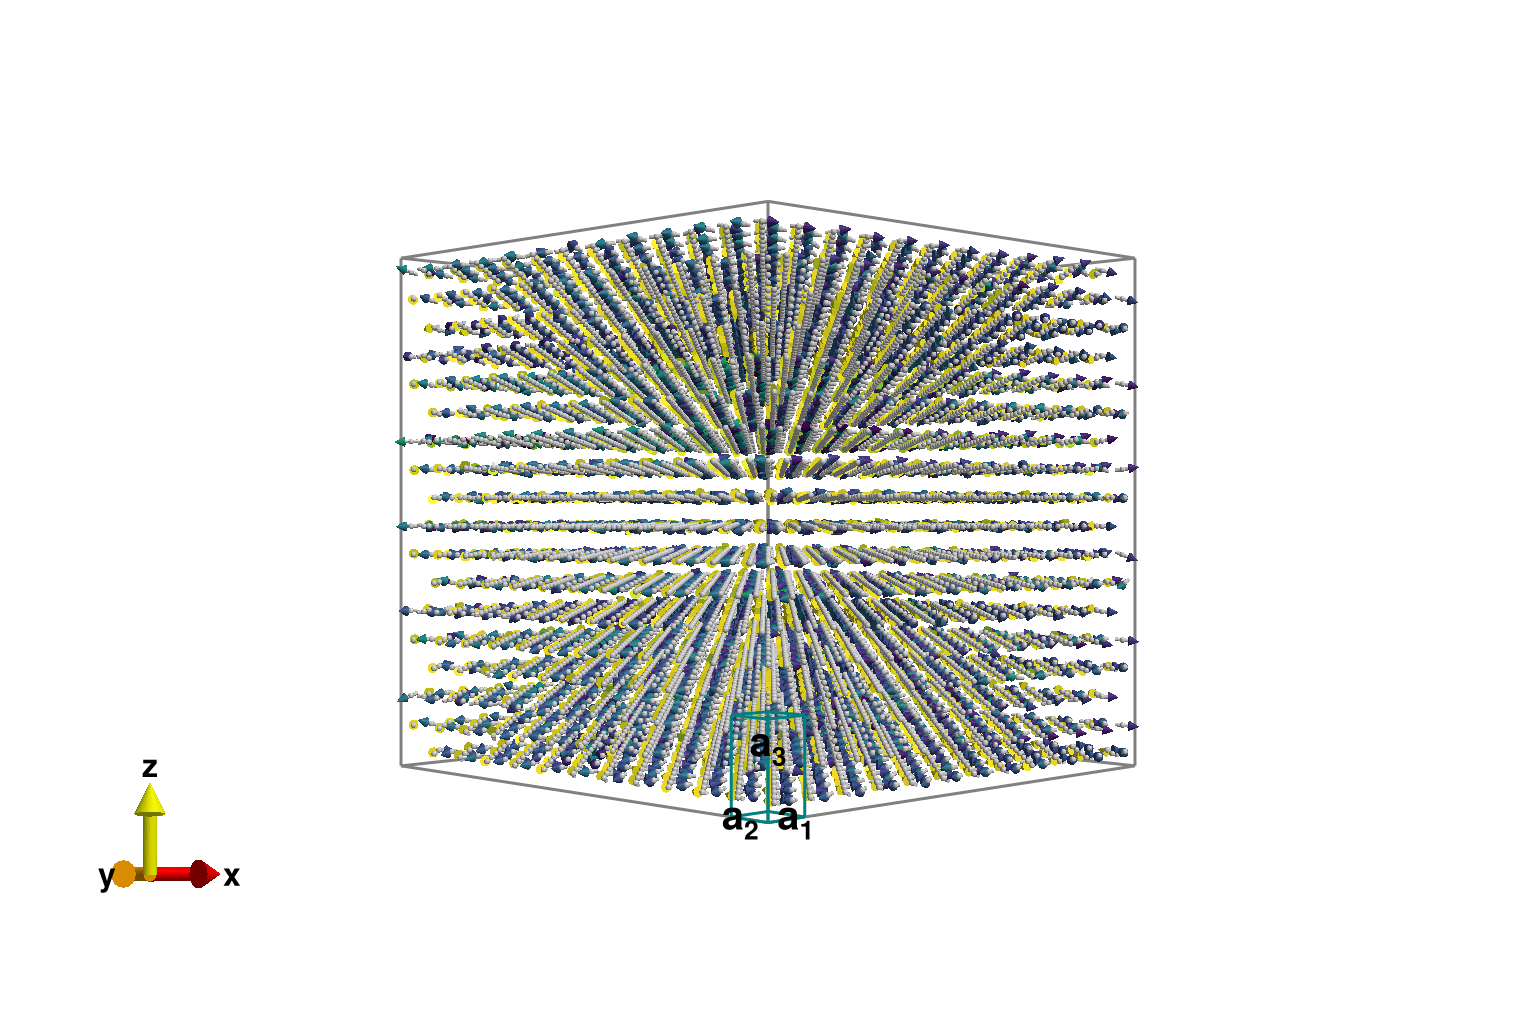

┌ Warning: error in renderloop
│   exception =
│    InterruptException:
│    Stacktrace:
│      [1] poptask(W::Base.IntrusiveLinkedListSynchronized{Task})
│        @ Base ./task.jl:1216
│      [2] wait()
│        @ Base ./task.jl:1228
│      [3] wait(c::Base.GenericCondition{Base.Threads.SpinLock}; first::Bool)
│        @ Base ./condition.jl:141
│      [4] _trywait(t::Timer)
│        @ Base ./asyncevent.jl:163
│      [5] wait
│        @ ./asyncevent.jl:202 [inlined]
│      [6] sleep
│        @ ./asyncevent.jl:312 [inlined]
│      [7] sleep(timer::Makie.BudgetedTimer)
│        @ Makie ~/.julia/packages/Makie/Vn16E/src/utilities/timing.jl:178
│      [8] (::GLMakie.var"#on_demand_renderloop##0#on_demand_renderloop##1"{GLMakie.Screen{GLFW.Window}})()
│        @ GLMakie ~/.julia/packages/GLMakie/vdrwE/src/screen.jl:1103
│      [9] with_context(f::GLMakie.var"#on_demand_renderloop##0#on_demand_renderloop##1"{GLMakie.Screen{GLFW.Window}}, context::GLFW.Window)
│        @ GLMakie.GLAbstraction

In [250]:
S0 = sys.dipoles[1,1,1,1]
plot_spins(sys; color=[S'*S0 for S in sys.dipoles])

In [144]:
formfactors = [1 => FormFactor("Fe3")]
measure = ssf_perp(sys; formfactors)
sc = SampledCorrelationsStatic(sys; measure)
add_sample!(sc, sys)

In [145]:
for _ in 1:20
    for _ in 1:100
        step!(sys, langevin)
    end
    add_sample!(sc, sys)
end

In [146]:
grid = q_space_grid(
    fe_cryst,
    [1, 0, 0], range(-10, 10, 1000),
    [0, 1, 0], range(-10, 10, 1000), orthogonalize=true
)


Sunny.QGrid{2} (1000×1000 samples)

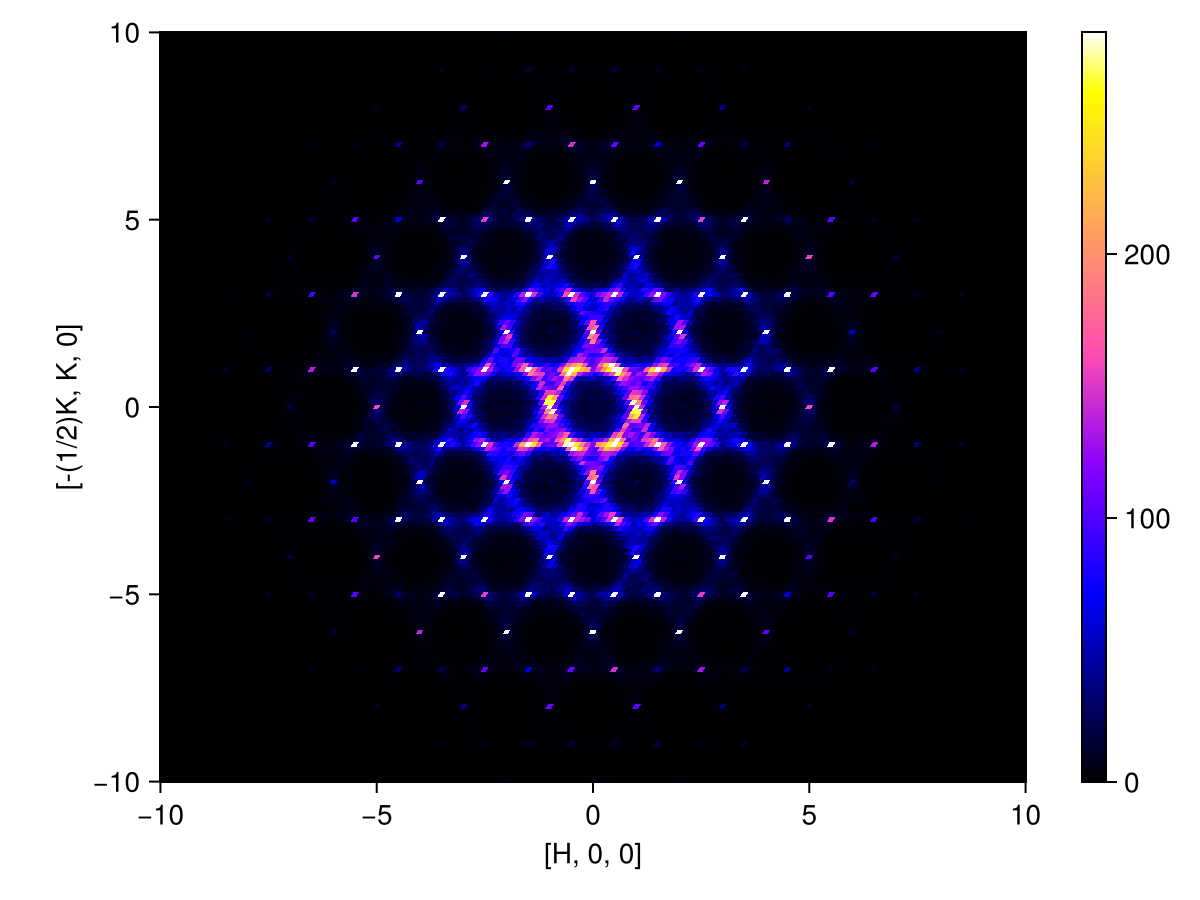

In [147]:
res = intensities_static(sc, grid)
using CairoMakie
plot_intensities(res)

In [150]:
energies = range(0, 25, 100)
dt = 2*langevin.dt
sc = SampledCorrelations(sys; dt, energies, measure)

for _ in 1:10
    for _ in 1:20
        step!(sys, langevin)
    end
    add_sample!(sc, sys)
end

res = intensities(sc, path1; energies, langevin.kT)
plot_intensities(res; units, title="Intensities at 70K")

LoadError: InterruptException: